In [1]:
from utils_functions import *

# Préparation de la data

In [2]:
def clean_and_prepare_data():
    print("Loading data...")
    df_posts = pd.read_csv('all_posts_active_subreddit.csv')
    df_com = pd.read_csv('all_comments.csv')


    bots_and_deleted = ['[deleted]', 'AutoModerator', 'RemindMeBot', 'WikiTextBot', 'image_linker_bot', 'sneakpeekbot']
    
    # Statistics before cleaning
    posts_before = len(df_posts)
    com_before = len(df_com)
    unique_authors_before = set(df_posts['Author'].unique()) | set(df_com['Author'].unique()) - {np.nan}
    
    # Cleaning
    df_posts = df_posts[~df_posts['Author'].isin(bots_and_deleted) & df_posts['Author'].notna()]
    df_com = df_com[~df_com['Author'].isin(bots_and_deleted) & df_com['Author'].notna()]
    
    # Statistics after cleaning
    posts_after = len(df_posts)
    com_after = len(df_com)
    unique_authors_after = set(df_posts['Author'].unique()) | set(df_com['Author'].unique())
    
    deleted_authors = unique_authors_before - unique_authors_after
    
    print(f"--- Data Preparation Summary ---")
    print(f"Unique authors removed: {len(deleted_authors)} ({', '.join(map(str, deleted_authors))})")
    print(f"Posts removed: {posts_before - posts_after}")
    print(f"Comments removed: {com_before - com_after}")
    print(f"Total rows dropped: {(posts_before - posts_after) + (com_before - com_after)}")
    print(f"--------------------------------")

    # Convert dates and get ISO week
    print("Extracting time windows...")
    df_posts['Date & Time'] = pd.to_datetime(df_posts['Date & Time'])
    df_com['Date & Time'] = pd.to_datetime(df_com['Date & Time'])
    
    df_posts['ISOYearWeek'] = df_posts['Date & Time'].dt.strftime('%G-W%V')
    df_com['ISOYearWeek'] = df_com['Date & Time'].dt.strftime('%G-W%V')
    
    print("Building interactions...")
    # Edge type 1: Comment -> Post
    df_com_post = df_com[df_com['Parent ID'].isna()].copy()
    df_com_post = df_com_post.merge(df_posts[['Post ID', 'Author', 'Subreddit']], on='Post ID', how='inner', suffixes=('_com', '_post'))
    df_com_post = df_com_post[df_com_post['Author_com'] != df_com_post['Author_post']]
    
    # Weight: 2 for replying to post, + 0.1 for every 10 chars of content
    df_com_post['Weight'] = 2.0 + (df_com_post['Content'].str.len().fillna(0) / 100.0)
    
    edges_post = df_com_post[['Author_com', 'Author_post', 'Subreddit', 'ISOYearWeek', 'Weight']].rename(
        columns={'Author_com': 'Source', 'Author_post': 'Target'}
    )
    
    # Edge type 2: Comment -> Comment
    df_com_com = df_com[df_com['Parent ID'].notna()].copy()
    df_com_com = df_com_com.merge(df_com[['Comment ID', 'Author']], left_on='Parent ID', right_on='Comment ID', suffixes=('_com', '_parent'))
    df_com_com = df_com_com[df_com_com['Author_com'] != df_com_com['Author_parent']]
    
    # Get Subreddit from Post
    df_com_com = df_com_com.merge(df_posts[['Post ID', 'Subreddit']], on='Post ID', how='inner')
    
    # Weight: 1 for replying to comment, + 0.1 for every 10 chars
    df_com_com['Weight'] = 1.0 + (df_com_com['Content'].str.len().fillna(0) / 100.0)
    
    edges_com = df_com_com[['Author_com', 'Author_parent', 'Subreddit', 'ISOYearWeek', 'Weight']].rename(
        columns={'Author_com': 'Source', 'Author_parent': 'Target'}
    )
    
    # Consolidate all edges
    all_edges = pd.concat([edges_post, edges_com], ignore_index=True)
    
    # Aggregate edge weights for same Source->Target within the same Subreddit and Week
    all_edges = all_edges.groupby(['Source', 'Target', 'Subreddit', 'ISOYearWeek'], as_index=False)['Weight'].sum()
    
    print("Saving consolidated edges...")
    if not os.path.exists('graphs'):
        os.makedirs('graphs')
        
    all_edges.to_csv('graphs/all_edges_consolidated.csv', index=False)
    
    print(all_edges.head())
    print("Pipeline completed.")



# Community detection

In [3]:
edges_file = 'graphs/all_edges_consolidated.csv'

G , G_directed = build_graph_from_data(edges_file)
#final_analysis = generate_analysis_report(G , G_directed)
#final_analysis[0].to_csv('graphs/node_metrics_undirected.csv', index=False)
#final_analysis[1].to_csv('graphs/node_metrics_directed.csv', index=False)

final_analysis = (pd.read_csv('graphs/node_metrics_undirected.csv'),
                    pd.read_csv('graphs/node_metrics_directed.csv'))


print("\n--- Top 5 Key Influencers (PageRank) ---")
print(final_analysis[0].sort_values(by='PageRank_Score', ascending=False).head())

Graph initialized: 49994 users, 151771 interactions.

--- Top 5 Key Influencers (PageRank) ---
                   User  Community_ID  Betweenness_Score  PageRank_Score  \
23      ClimateShitpost            55           0.057705        0.006135   
420          idspispopd            19           0.044691        0.005412   
246   livinginahologram             0           0.055989        0.003818   
63   logicalprogressive           146           0.042982        0.003775   
229       suspended_007           146           0.025897        0.003739   

     Coreness_Level  Degree     Network_Role  
23               15    1298  Core (Backbone)  
420              20    1138  Core (Backbone)  
246              19    1350  Core (Backbone)  
63               27    1554  Core (Backbone)  
229              27    1449  Core (Backbone)  


# Dynamic analysys

In [4]:
#weekly_metrics = compute_all_weekly_metrics(edges_file)
weekly_metrics = pd.read_csv('graphs/dynamic_metrics.csv')
print("all subreddits:")
print(weekly_metrics["Subreddit"].unique())

all subreddits:
['ClimateOffensive' 'climatechange' 'climateskeptics' 'ClimateShitposting'
 'ExtinctionRebellion' 'ClimateActionPlan' 'Green' 'Climate_Nuremberg'
 'ClimateNews' 'ecologie' 'SunriseMovement' 'climatesolutions'
 'ClimateCrisisCanada' 'Ecologisme' 'FridaysForFuture'
 'climate_discussion' 'ClimateCO' 'climatepolicy' 'greenpeace'
 'climatejustice']


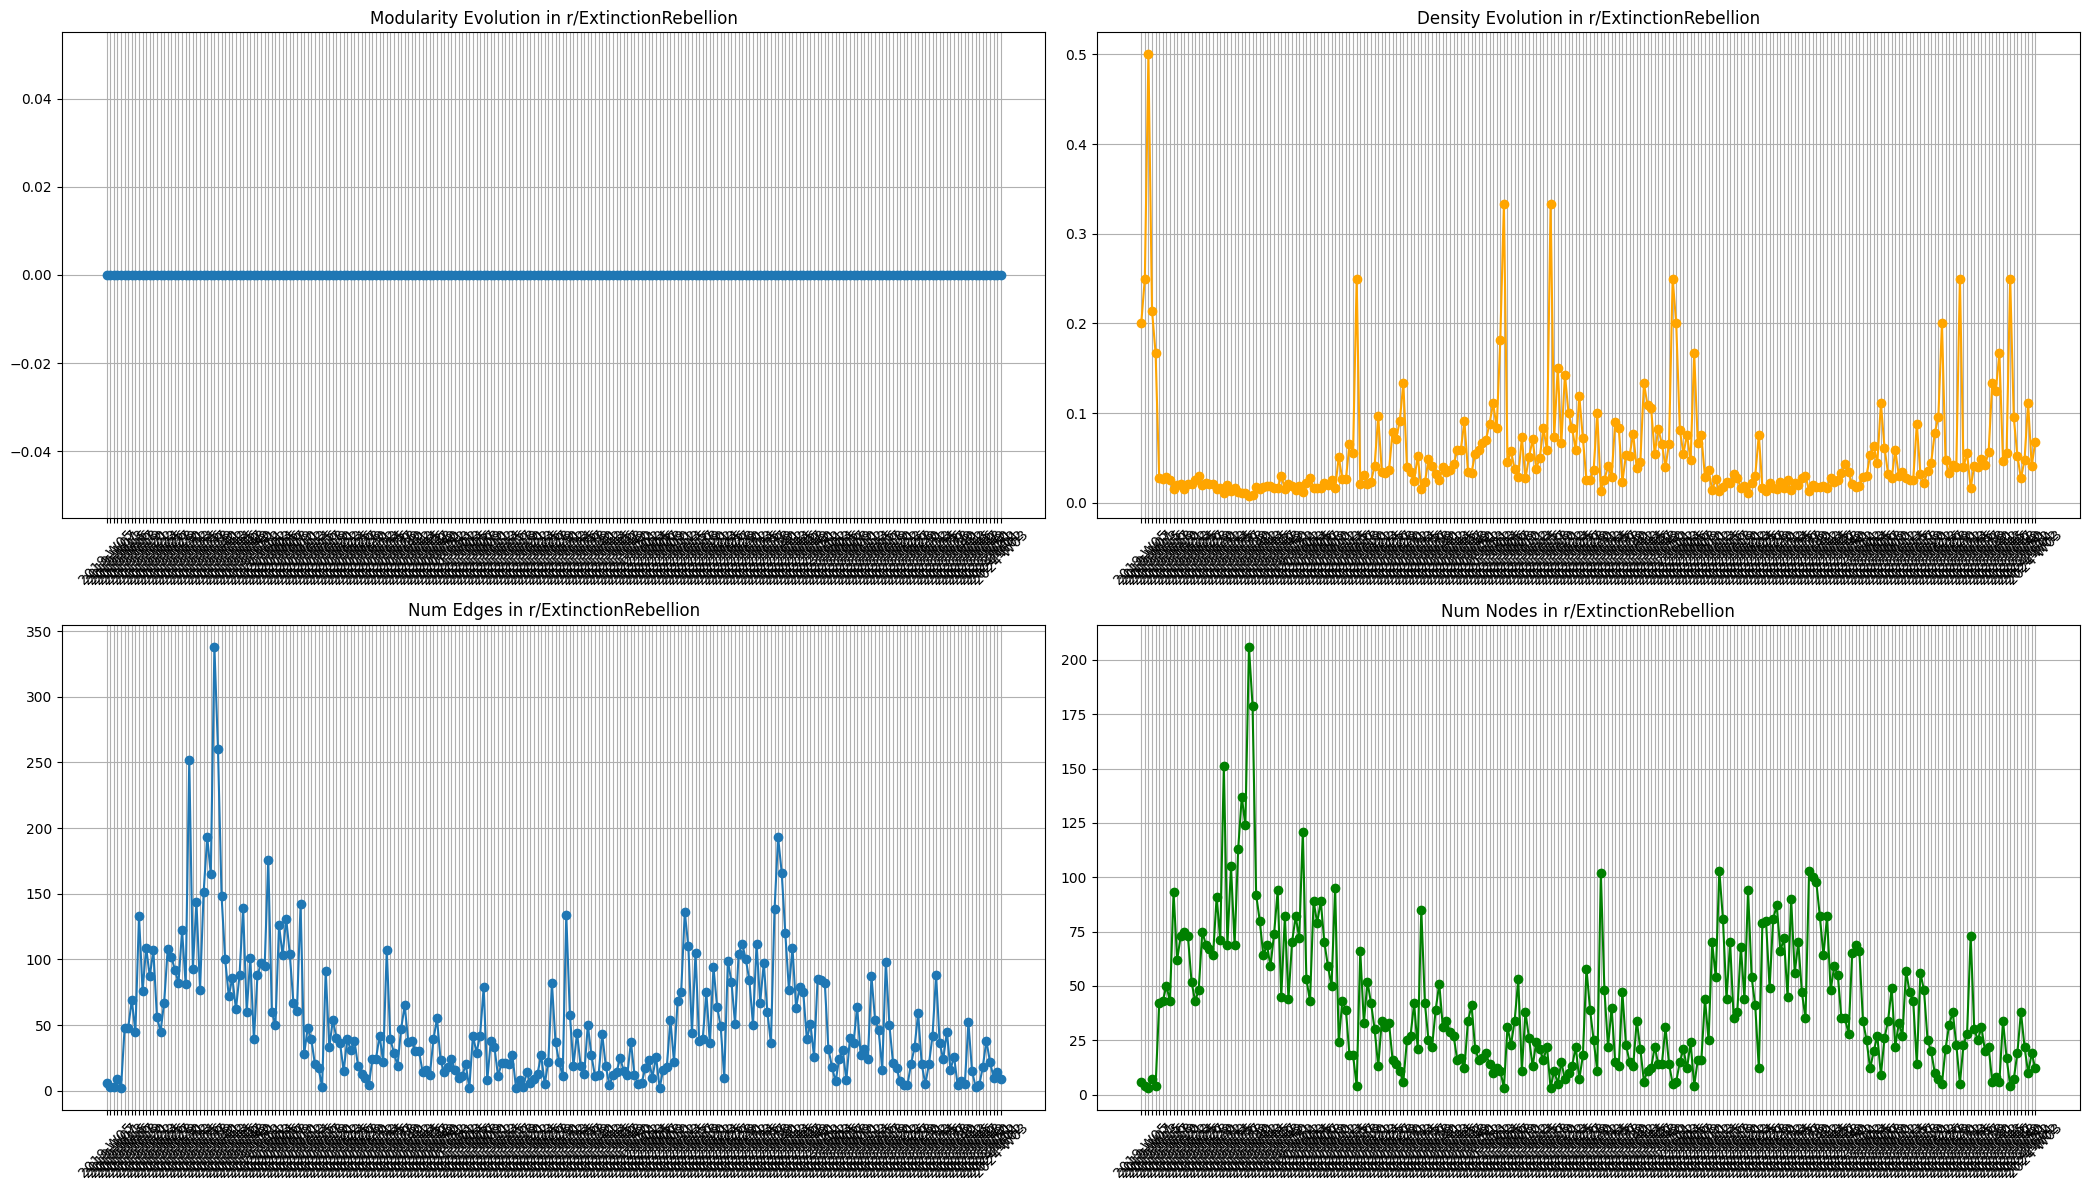

In [5]:
plot_subreddit_metrics(weekly_metrics,"ExtinctionRebellion")

# Anomaly detection

In [6]:
from utils_2_functions import *

Threshold (99th percentile): 3.12


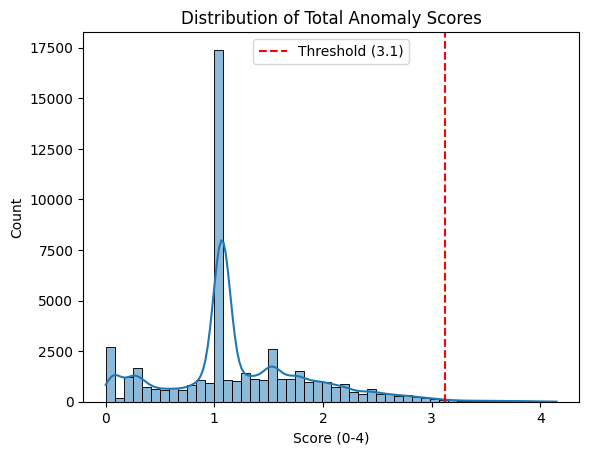

In [7]:
node_metrics = final_analysis[1].copy()
dynamic_metrics = weekly_metrics.copy()

node_metrics = measure_grades(node_metrics, dynamic_metrics)


        DETECTION SUMMARY STATISTICS        

--- Continuous Grade Statistics (0.0 to 1.0) ---
                       Mean   Std Dev           Min  Median (50%)      Max
Grade_Spammer      0.243082  0.261247  5.037196e-06      0.111624  1.00000
Grade_Bridger      0.238923  0.257765  8.002881e-15      0.332212  1.00000
Grade_Peripheral   0.243612  0.276529  1.575207e-10      0.224271  0.99994
Grade_Leader       0.017792  0.105594  0.000000e+00      0.000000  1.00000
Grade_Burstiness   0.238375  0.295417  0.000000e+00      0.027960  1.00000
Grade_Instability  0.006016  0.058745  0.000000e+00      0.000000  1.00000
Grade_BotRing      0.246929  0.284876  8.002881e-15      0.041545  1.00000

--- Binary Anomaly Flag Counts ---
          Flag Name  Number of Users
         Is_Spammer             3622
          Is_Bursty             1814
         Is_Bridger             1726
      Is_Peripheral             1607
          Is_Leader             1522
        Is_Unstable             1522
   Is_Sup

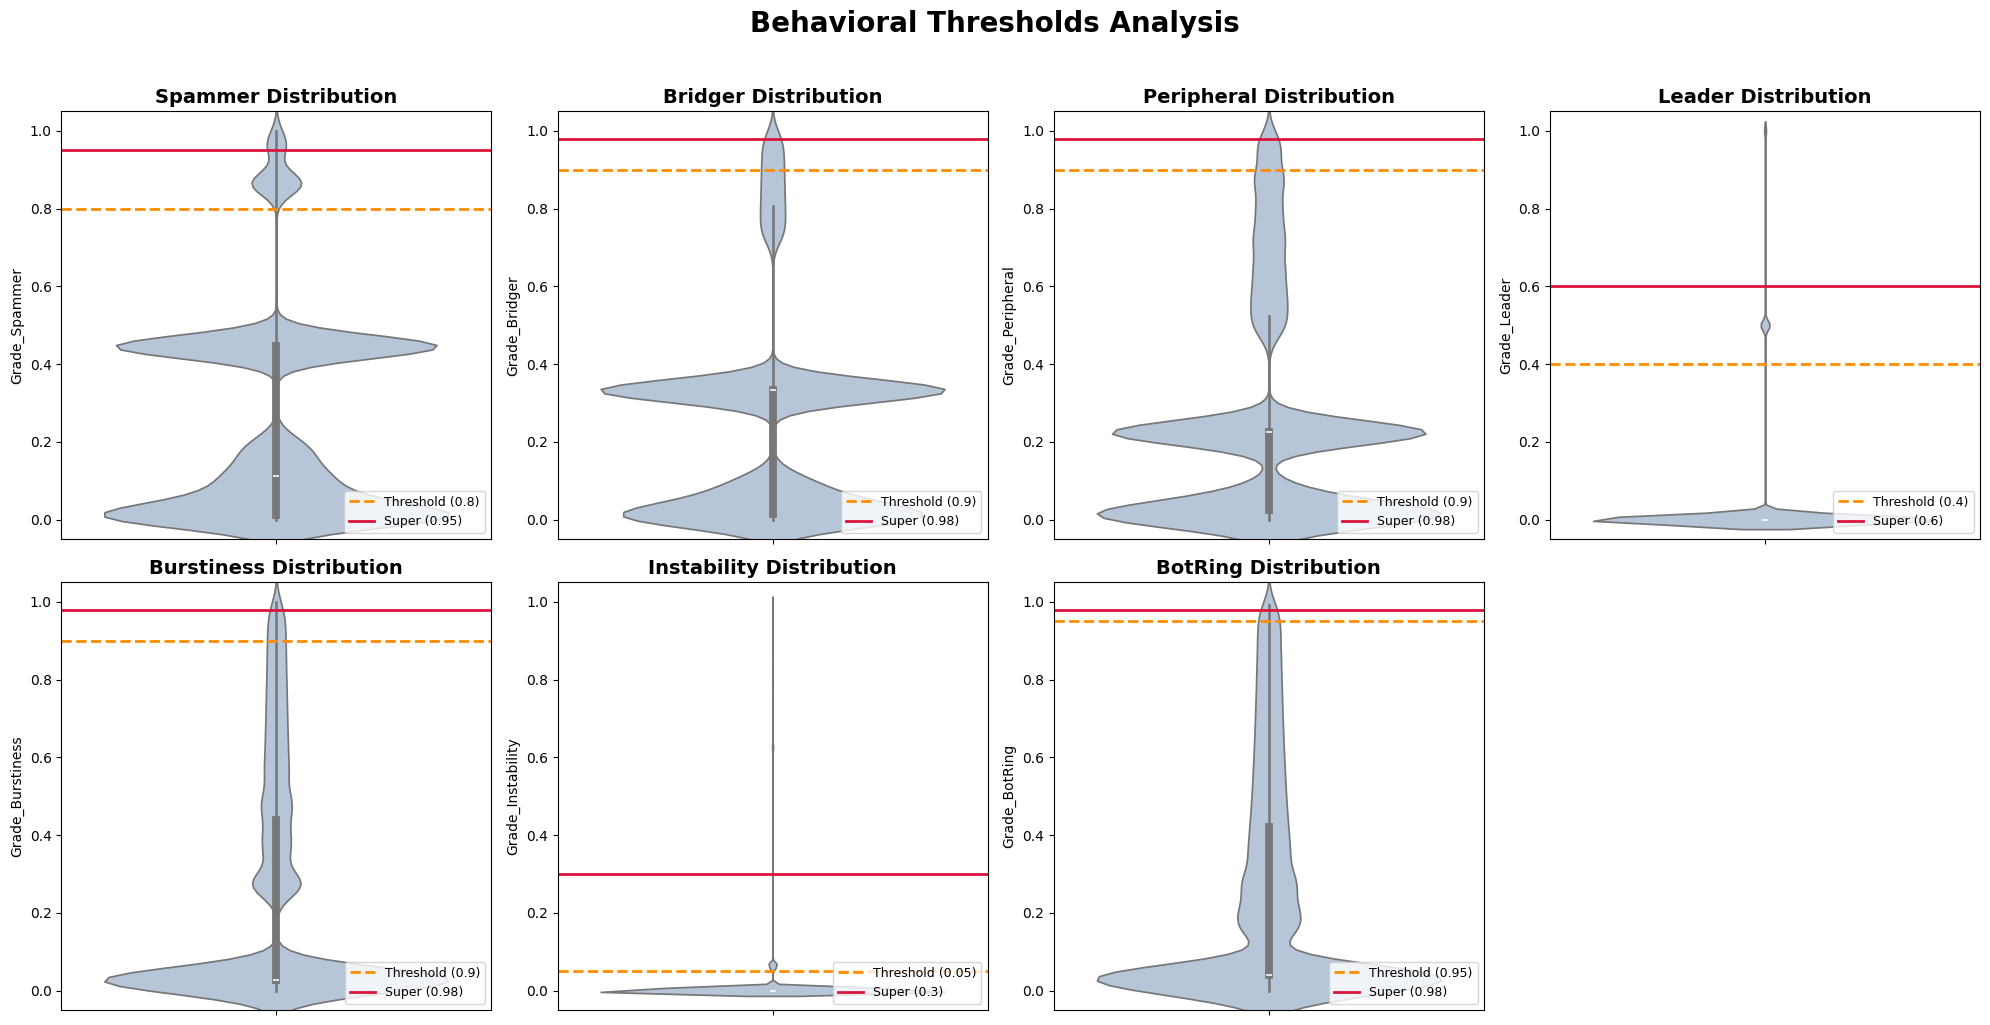

c:\Users\Users\Desktop\vialactée\Graph_Theory_Challenge_2\utils_2_functions.py:245: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=node_metrics, x='Total_Red_Flags', ax=axes[0, 1], palette='Reds')
c:\Users\Users\Desktop\vialactée\Graph_Theory_Challenge_2\utils_2_functions.py:256: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_15, x='Total_Anomaly_Score', y='User_Str', ax=axes[1, 0], palette='magma')


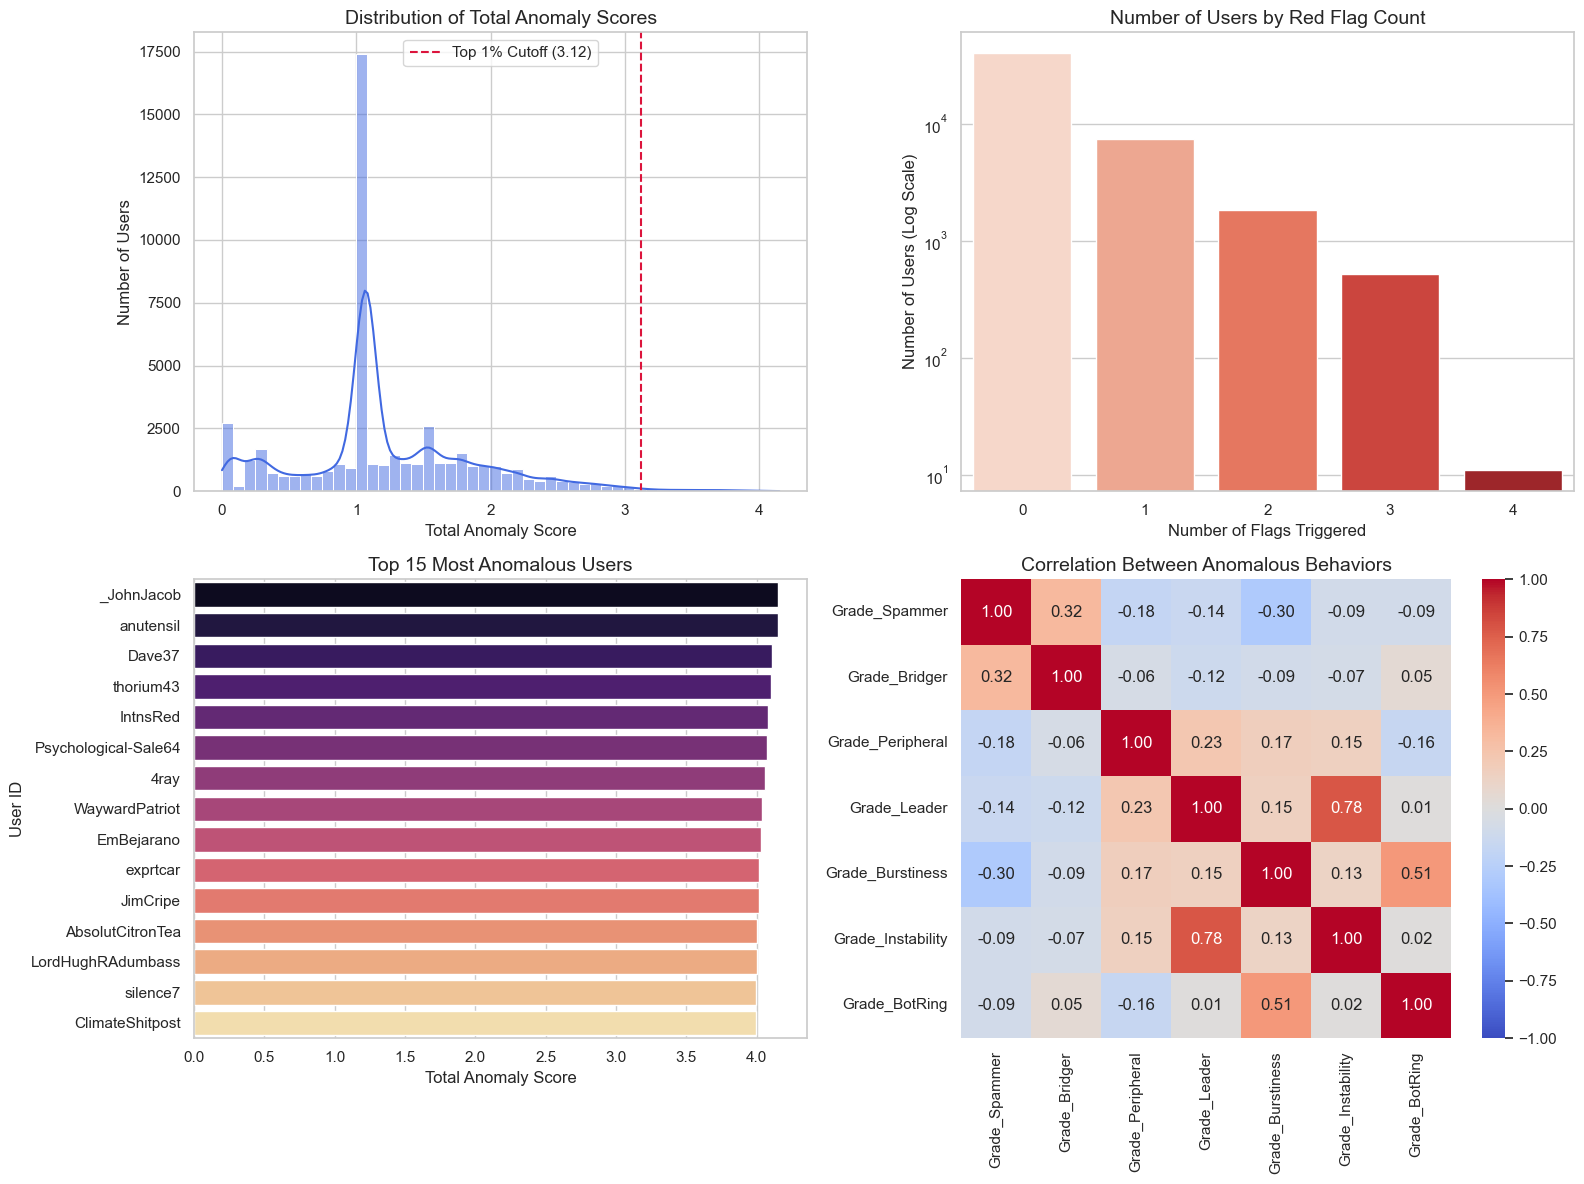

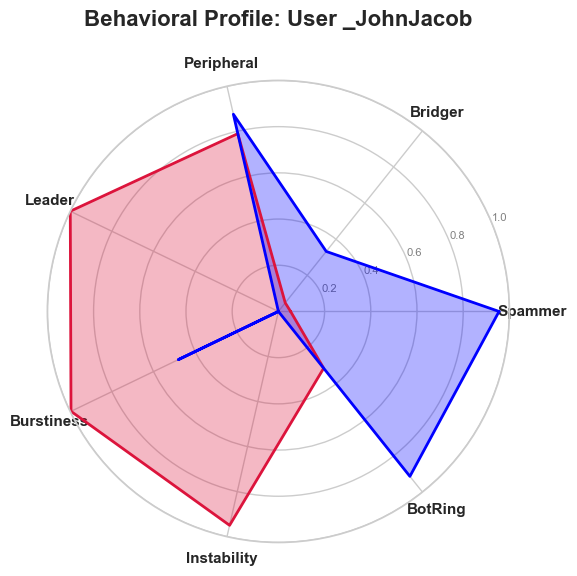

Nb of anomalous users :  295


In [8]:
anomalous_users , node_metrics = detect_dynamic_anomalies(node_metrics =  node_metrics,
                                                 global_threshold = 3.7,
                                                 nb_of_flags = 4)

In [9]:
alerts = detect_anomalies(final_analysis[0])
alert_community_manager(alerts)

🚨 ALERT: 31 suspicious users flagged for DSA review.
------------------------------
                    User                    Type  \
0    Reasonable_doubt_59  Suspicious Core Member   
28            pwrboredom  Suspicious Core Member   
27           Ok_Sea_6214  Suspicious Core Member   
26            beowulftoo  Suspicious Core Member   
25  Revenant_adinfinitum  Suspicious Core Member   
24  Delicious_Summer7839  Suspicious Core Member   
23              jsideris  Suspicious Core Member   
22         Savant_Guarde  Suspicious Core Member   
21               tensigh  Suspicious Core Member   
20  therealdocumentarian  Suspicious Core Member   
19       RealityCheck831  Suspicious Core Member   
18        user4517proton  Suspicious Core Member   
17         WolfieTooting  Suspicious Core Member   
16    TheRealAuthorSarge  Suspicious Core Member   
29          Traveler3141  Suspicious Core Member   
15            Reaper0221  Suspicious Core Member   
13         Moses_Horwitz  Suspic

# Verification

Loading all comments...
Extracted 39832 comments generated by the anomalous users.
Calculating sentiment polarity for anomalous users' comments...
Calculating sentiment polarity for a random sample of normal users...
nb de normal users :  52351
nb de anomalous users :  295
nb de alert users :  31


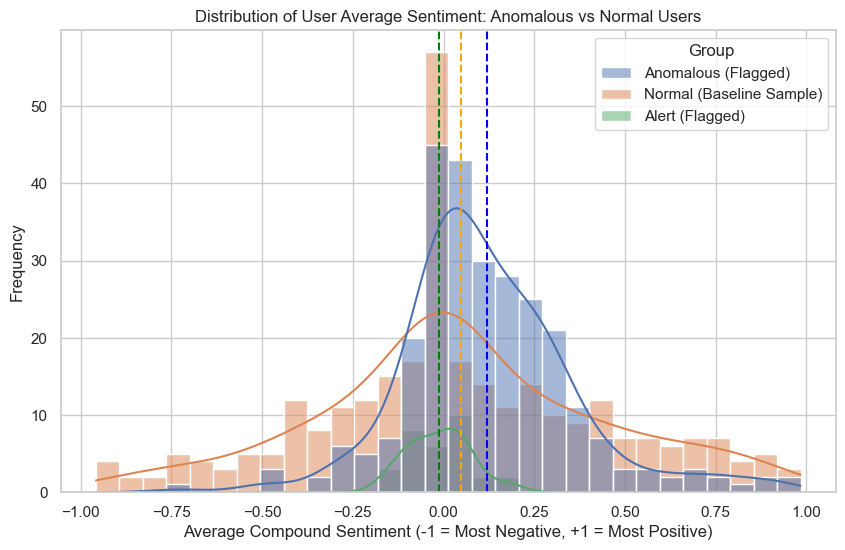

Top 10 Most Negative Anomalous Users:


,Author,Sentiment_Compound,Group
46,Dobis87_,-0.727800,Anomalous (Flagged)
86,Katatad,-0.493900,Anomalous (Flagged)
246,sterretjesswag2,-0.490200,Anomalous (Flagged)
260,troglozyte,-0.477900,Anomalous (Flagged)
157,acusticthoughts,-0.316100,Anomalous (Flagged)
229,optionhome,-0.314233,Anomalous (Flagged)
111,Numerous_Recording87,-0.308900,Anomalous (Flagged)
98,LyraSerpentine,-0.283893,Anomalous (Flagged)
177,caseyoli,-0.276543,Anomalous (Flagged)
130,Soujanya7789,-0.273200,Anomalous (Flagged)


In [10]:
alert_users = alerts['User'] 
compare_anomalies(anomalous_users , alert_users)

In [11]:
core_list = final_analysis[0][final_analysis[0]['Network_Role'] == 'Core (Backbone)']['User'].tolist()
alert_list = alerts['User'].tolist()
anomalous_list  = anomalous_users
# Prove the core is the "Backbone"
frag_score = test_network_robustness(G, core_list)

community_mapping = detect_communities(G)
# Prove that removing anomalies cleans the network
print('\n')
print("result for alert list : ")
mod_before, mod_after = evaluate_filtering_impact(G, alert_list, community_mapping)
print("\n")
print("result for anomalous list : ")
mod_before, mod_after = evaluate_filtering_impact(G, anomalous_list, community_mapping)


--- Robustness Testing (Structural Pillars) ---
Initial LCC Size: 49547
LCC Size after Core Removal: 15097
Network Fragmentation: 69.53% drop in connectivity.
Community Detection: Found 270 distinct groups.


result for alert list : 

--- Metric Evaluation (Noise Filtering) ---
Original Modularity: 0.6779
Filtered Modularity: 0.6796
Improvement: 0.25%


result for anomalous list : 

--- Metric Evaluation (Noise Filtering) ---
Original Modularity: 0.6779
Filtered Modularity: 0.6777
Improvement: -0.02%


Creating clean graph...

=== BASIC STATS ===
Nodes Removed: 295 (0.59% of network)
Edges Removed: 33766 (22.25% of network)
💡 INSIGHT: Highly disproportionate edge removal. These were likely spammers/hubs!

=== CALCULATING STRUCTURAL HEALTH ===
Assortativity: Original=-0.0973, Cleaned=-0.0272
Giant Component: Original=49547 nodes, Cleaned=43190 nodes
Calculating Average Clustering (This may take a moment)...
Avg Clustering: Original=0.0976, Cleaned=0.0471


c:\Users\Users\Desktop\vialactée\Graph_Theory_Challenge_2\utils_2_functions.py:440: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame(density_data), x='Graph', y='Density', ax=axes[0], palette='Blues_d')
c:\Users\Users\Desktop\vialactée\Graph_Theory_Challenge_2\utils_2_functions.py:485: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_impact, x='Category', y='Percentage', ax=axes[4], palette='Reds_r')


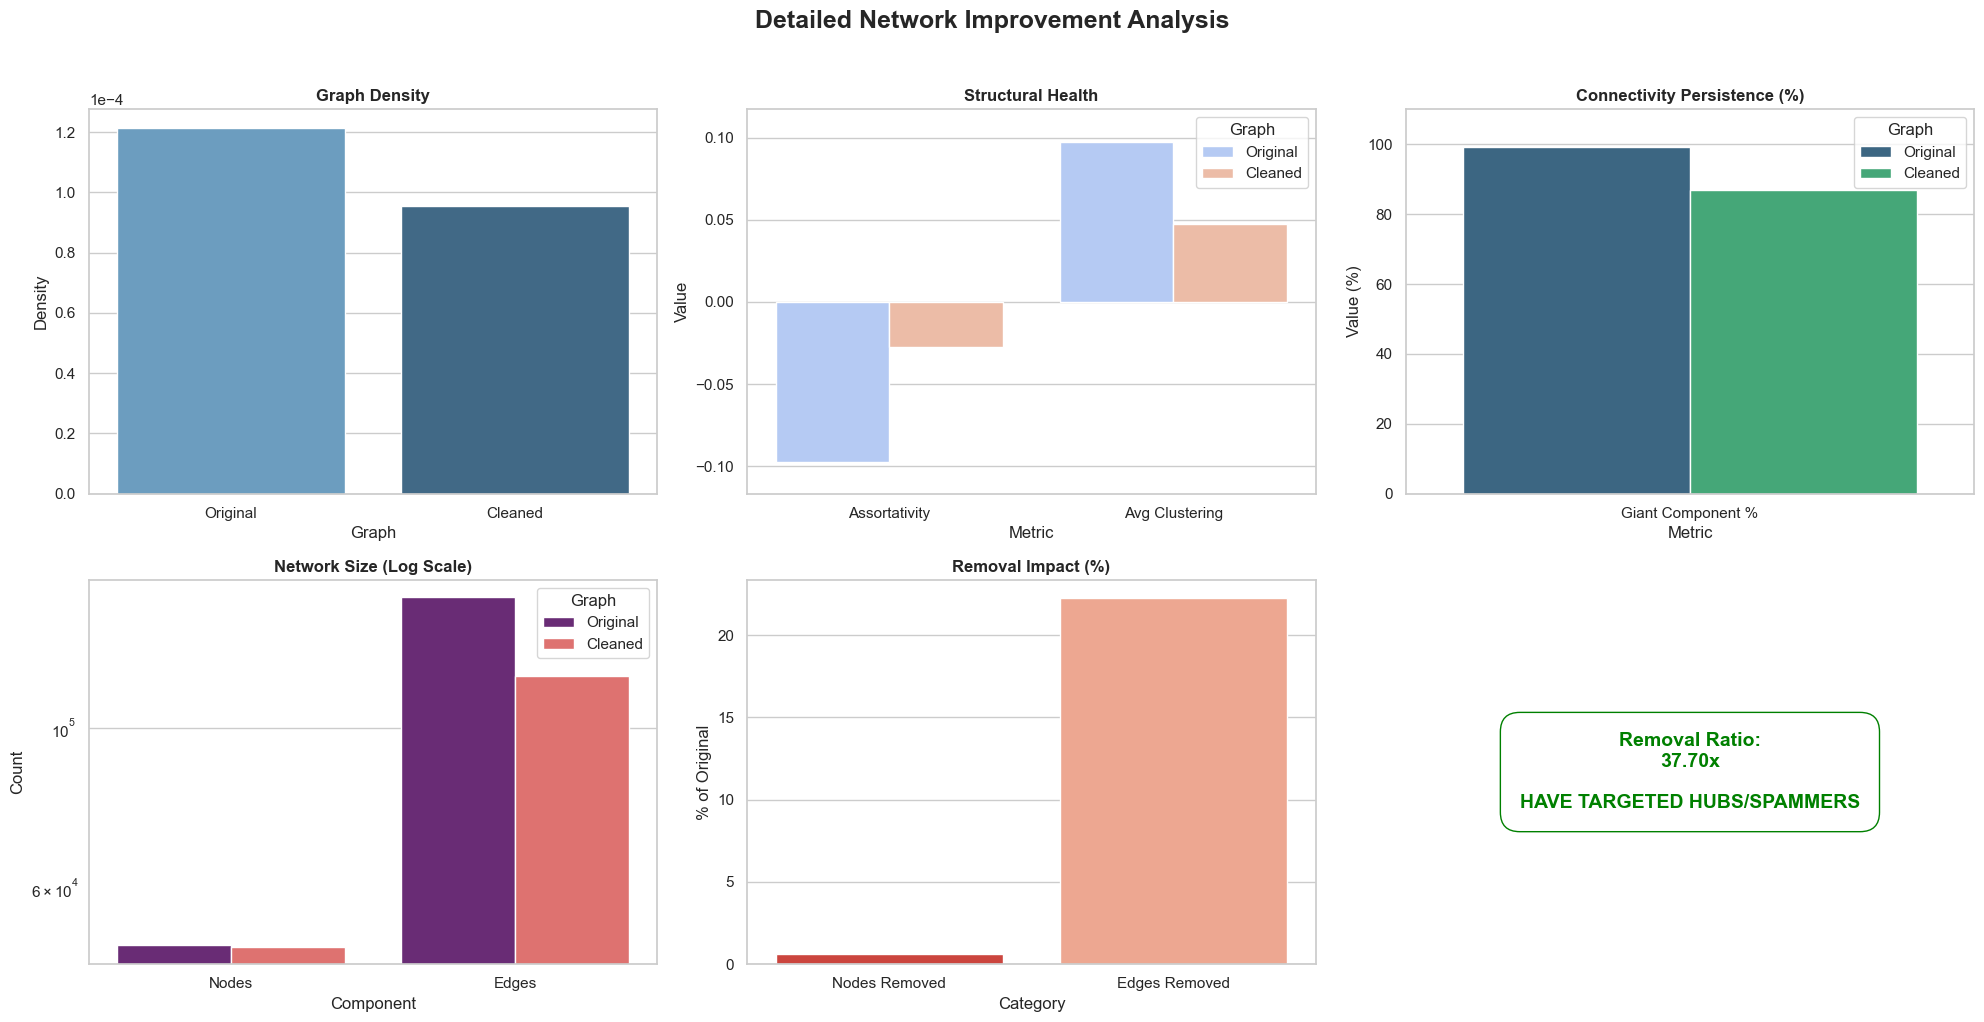

In [12]:
G_clean = test_graph_improvement(G, anomalous_users)

Creating clean graph...

=== BASIC STATS ===
Nodes Removed: 31 (0.06% of network)
Edges Removed: 3337 (2.20% of network)
💡 INSIGHT: Highly disproportionate edge removal. These were likely spammers/hubs!

=== CALCULATING STRUCTURAL HEALTH ===
Assortativity: Original=-0.0973, Cleaned=-0.0993
Giant Component: Original=49547 nodes, Cleaned=49426 nodes
Calculating Average Clustering (This may take a moment)...
Avg Clustering: Original=0.0976, Cleaned=0.0966


c:\Users\Users\Desktop\vialactée\Graph_Theory_Challenge_2\utils_2_functions.py:440: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame(density_data), x='Graph', y='Density', ax=axes[0], palette='Blues_d')
c:\Users\Users\Desktop\vialactée\Graph_Theory_Challenge_2\utils_2_functions.py:485: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_impact, x='Category', y='Percentage', ax=axes[4], palette='Reds_r')


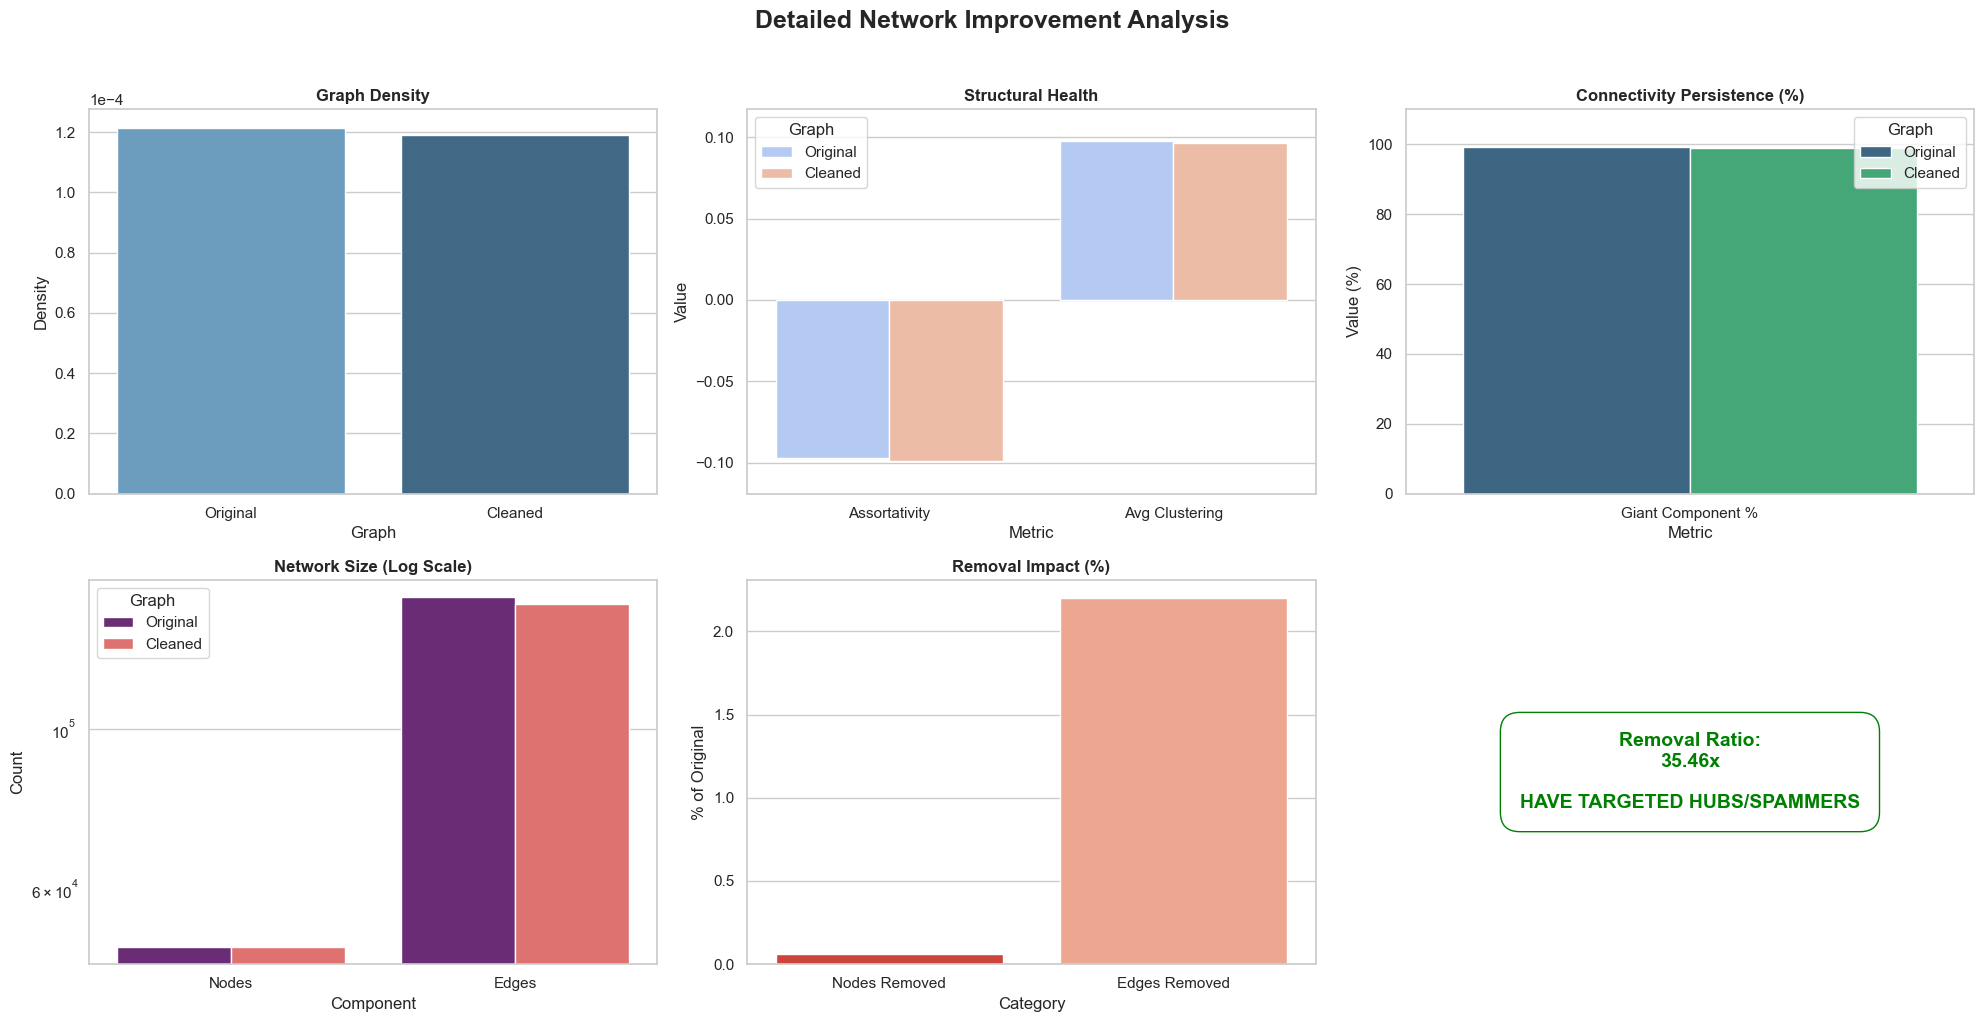

In [13]:
G_clean = test_graph_improvement(G, alert_users)